In [ ]:
import asyncio
import logging
from pathlib import Path
import typing as typ


import json
import matplotlib.pyplot as plt

import aiohttp
import json_numpy
import numpy as np
import numpy.typing as npt
import SimpleITK as sitk
from rich.logging import RichHandler

from isodose_colors import IsodoseColors

In [ ]:
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.propagate = False

log_format = logging.Formatter('%(message)s')
console_handler = RichHandler()
console_handler.setFormatter(log_format)
logger.addHandler(console_handler)

In [ ]:
def ct_norm(
    image: sitk.Image, min_value: float, max_value: float
) -> sitk.Image:
    """Normalize a CT (or other) image between a minimum and maximum intensity,
    then rescale to the range 0-1
    Args:
        image:      A 3D SimpleITK image
        min_value:  Float, the minimum value to clip the existing image to
        max_value:  Float, the maximum value to clip the existing image to

    Returns:
        A SimpleITK image
    """
    # Don't use sitk.sitkInt16 (or any other integer type)! It will
    # give a substantially truncated result with sitk.RescaleIntensity
    clipped = sitk.Clamp(image, sitk.sitkFloat32, min_value, max_value)
    return sitk.RescaleIntensity(clipped, outputMinimum=0, outputMaximum=1)


def dilate_region(
    image: sitk.Image,
    radius: typ.Sequence[int],
    background: float = 0.0,
    foreground: float = 1.0,
):
    return sitk.BinaryDilate(
        image,
        kernelRadius=radius,
        backgroundValue=background,
        foregroundValue=foreground,
    )

In [ ]:
def encode_request(**kwargs):
    """Encode request data into JSON format"""
    try:
        return json_numpy.dumps(kwargs)
    except Exception as e:
        logger.exception(f'Error encoding request: {e}')
        raise

In [ ]:
async def make_prediction_request(
    data: str, server_url: str | None = None
) -> typ.Union[npt.NDArray, None]:
    """Make async prediction request to server

    Args:
        data:       The request payload to send to the prediction
                    server. This should be JSON-encoded.

        server_url: String, the  default server URL.

    Returns:
        Predicted dose array or None if an error occurred

    Raises:
        RuntimeError: If server returns a non-200 status code
        Exception: For any other errors during the request
    """
    # Configure timeout and retry parameters
    timeout = aiohttp.ClientTimeout(
        total=300,
        connect=30,
    )
    max_retries = 5
    retry_count = 0
    base_delay = 1.0

    while retry_count <= max_retries:
        try:
            async with aiohttp.ClientSession(timeout=timeout) as session:
                async with session.post(
                    server_url, json={'input': data}
                ) as response:
                    # Handle server busy (503) status
                    if response.status == 503:  # Server busy
                        retry_delay = base_delay * (
                            2**retry_count
                        )  # Exponential backoff
                        logger.info(
                            f'Server busy. Retrying in {retry_delay:.1f}s (attempt {retry_count + 1}/{max_retries + 1})'
                        )
                        await asyncio.sleep(retry_delay)
                        retry_count += 1
                        continue

                    # Handle other non-200 responses
                    if response.status != 200:
                        error_text = await response.text()
                        logger.error(
                            f'Failed to get response from the server, status code: {response.status}, '
                            f'response: {error_text}...'
                        )
                        raise RuntimeError(
                            f'Failed to get response from server (status={response.status})'
                        )

                    # Process successful response
                    result = await response.json()
                    pred_dose = json_numpy.loads(result['output'])
                    return pred_dose

        except aiohttp.ClientError as e:
            # Retry for network errors
            retry_count += 1
            if retry_count <= max_retries:
                retry_delay = base_delay * (2**retry_count)
                logger.warning(
                    f'Connection error: {e}. Retrying in {retry_delay:.1f}s (attempt {retry_count}/{max_retries + 1})'
                )
                await asyncio.sleep(retry_delay)
            else:
                logger.exception(
                    f'Connection failed after {max_retries + 1} attempts: {e}'
                )
                raise RuntimeError(
                    f'Failed to connect to prediction server after {max_retries + 1} attempts'
                ) from e

        except Exception as e:
            # Exit immediately for other errors
            logger.exception(f'Error in prediction request: {e}')
            raise
    return None

In [ ]:
def dose_fmt(x: float) -> str:
    return '%i cGy' % x

# GPU Listener Workshop

This is an instructional notebook for interacting with the [GPU Listener](https://github.mdanderson.org/SGay1-PhD-Project/GPU-Listener) project that runs the deep learning models from Skylar's PhD project that edit dose based on language inputs. 

This approach is a little different than you may be used to. You've probably done something like this in the past: in Seadragon, run a python script that loads model weights and runs predictions on a folder of numpy arrays. Or even more abstractly, just run a Kubernetes job where all the code was pre-configured.

That works great if you are trying to predict for some pre-defined inputs that are already saved to disk. You're just loading a model, the code scans a folder, and the arrays are given to the model that then saves the output to another folder. Everything shuts down at the end. Quick and simple.

But what if you don't fully know your inputs ahead of time? You could scan a folder for inputs (e.g., with a `while` loop) , and run the model when certain conditions occur like particular files appearing. But filesystems are finicky, and files don't always update immediately. Or what if you need the model to always be loaded and ready to go, without having to load the weights each time you want to make a prediction? This can't be done with the standard queues on seadragon. Finally, how would you replicate your models across several GPUs, so that you can run more than one prediction at a time without the GPUs conflicting with each other or duplicating effort? Again, this isn't easily done on seadragon.

Therefore, this approach does the following:

1. At start-up, the models are loaded once, and then just wait for input.
   
2. The models are automatically replicated across all available GPUs. If you have 1 GPU, then you can run 1 prediction at a time. If you have 4, then you can run 4 simultaneously, and so on. You do not need to worry about what data goes to what GPU. This system handles it all for you. Nor do you have to wait for one job to finish before submitting the next. If more prediction requests are submitted than GPUs available, the requests are automatically queued and run as GPUs become available.

   
3. Inputs are provided over the **network**, not read from a file system. This is one of the biggest differences of this approach. To send a Numpy array for prediction, you do not save it to a folder. Instead, you load it (on your computer), encode it as a JSON structure (again, on your computer), and then use an HTTTP POST method to send it to the deep learning server for prediction.

If some of this isn't familiar, don't worry! We'll walk through a concrete example of everything you need to do.

## Setup
First, we'll need to set up the listener service on a GPU-enabled server. The listener is in a Docker image, and weights are stored separately to avoid blowing up the image size.
You should only have to do this one time.

Let's start by copying the model weights to the GPU server. I have saved them in my PhD Project folder. To get them onto the DGX, you can use the following commands:

```bash
cp -r /mnt/court-lab/Skylar/PhD_Project/Webtrain_Data/Weights ${HOME}/gpu_listener_weights
```

(You may need to adjust this somewhat if you're on a different system.)


Next, you'll need to get the GPU Listener code. It's easiest to pull the source code and change one configuration file there, then use that to pull and start the Docker image.

```bash
git clone https://github.mdanderson.org/SGay1-PhD-Project/GPU-Listener.git gpu_listener
cd gpu_listener
```

There is only one thing you need to configure: the path to the weights. They are saved in your `${HOME}/gpu_listener_weights`. You'll need the **full** path. If you don't know what that is, run `echo ${HOME}/gpu_listener_weights` and copy the output. Then open the "docker-compose.yml" file and change the "device" line to be the full path to the weights.

```yaml
volumes:
  weights:
    driver: local
    driver_opts:
      o: bind
      type: none
      device: /raid/sgay1/data/train_pilot/weights/   # CHANGE this line
```


Finally, pull the Docker image
```bash
docker compose pull
```

If you get an error that it cannot access the registry, run `docker login hpcharbor.mdanderson.edu` and try again.

## Sample Data

You will also need some sample data - an example patient. This should be saved onto your own machine (not the DGX). What we're demonstrating here is the **network**-based approach to making and receiving predictions. The data does not have to be on the same machine as the GPUs/deep learning models, but is sent over the network (in JSON format) each time you make a request.

First, copy the data onto your computer. I have it on the Courtyard W drive - W:\Skylar\PhD_Project\Webtrain_Data
sample_data. Copy the sample_data folder into this project (you can just drag and drop in Jupyter).

There are some assumptions that the code makes about the input data. This is all true for the sample data I've provided, but if you use your own data you need to check & adjust as needed:

- All input volumes have $3\mathrm{mm} \times 3\mathrm{mm} \times 3\mathrm{mm}$ voxel spacing
- The primary prescription is known in terms of cGy, and is between 6000-7000 cGy
- The following data is reqired
  - A CT
  - A starting dose distribution
  - A dose mask
  - A target mask of one or more targets, with the prescribed dose level to each as the voxel values (e.g. [0, 5600, 6300, 7000] as unique values)
  - A mask of the OAR to which the change should be made

*Technically, if you don't have a dose mask, you could generate one on the fly from the starting dose distribution by setting all voxels greater than 0 as 1. Also, if you have separate target arrays and know the prescription value for each, you can generate the target masks with encoded prescriptions by multiplying the target masks by the prescriptions.*


We will then make the following transformations to get the data in the format that is accepted by the model:

1. Normalize the CT by clipping to the HU values [-200, 450], then performing a linear rescale to the range [0, 1]
2. Expand the OAR region with a binary dilation operation. This should add a 1.5cm margin in each direction with the (5, 5, 5) kernel. This is (one of) the regions the voxel spacing is important, so that the dilation adds the correct margin.


In [ ]:
data_dir = Path('sample_data')

In [ ]:
ct = sitk.ReadImage(data_dir / 'SG_HN_309_image.nii.gz')
ct = ct_norm(ct, min_value=-200, max_value=450)

start_dose = sitk.ReadImage(data_dir / 'SG_HN_309_dose_clinical.nii.gz')
mask_dose = sitk.ReadImage(data_dir / 'SG_HN_309_mask_dose.nii.gz')
mask_targets = sitk.ReadImage(data_dir / 'SG_HN_309_mask_ptvs.nii.gz')

mask_oar = sitk.ReadImage(data_dir / 'SG_HN_309_mask_Parotid_R.nii.gz')
dilated_oar = dilate_region(mask_oar, radius=(5, 5, 5))

Verify that the voxel spacing is $3\mathrm{mm} \times 3\mathrm{mm} \times 3\mathrm{mm}$

In [ ]:
ct.GetSpacing()

(3.0, 3.0, 3.0)

Convert to numpy arrays

In [ ]:
ct = sitk.GetArrayFromImage(ct).astype(float)
start_dose = sitk.GetArrayFromImage(start_dose).astype(float)
mask_dose = sitk.GetArrayFromImage(mask_dose).astype(bool)
mask_targets = sitk.GetArrayFromImage(mask_targets).astype(int)
dilated_oar = sitk.GetArrayFromImage(dilated_oar).astype(bool)

# Not needed here but needed later when plotting
mask_oar = sitk.GetArrayFromImage(mask_oar).astype(bool)

If you check the unique values of the target masks, you'll see that the prescription values are already encoded. Note also that this is why we specified it as an integer type, while masks are typically boolean types. We need more than True/False, we need to know the specific dose levels prescribed to each target.

In [ ]:
np.unique(mask_targets)

array([   0, 5600, 6000, 6600, 6996])

Finally, all dose values are normalized by 1.2 times the primary prescription. In this case, we know that this is 6996cGy.

In [ ]:
rx = np.unique(mask_targets).max()
dose_ceil = 1.2 * rx

In [ ]:
vol_inputs = np.stack(
    [
        ct,
        start_dose / dose_ceil,
        mask_dose,
        mask_targets / dose_ceil,
        dilated_oar
        * mask_dose,  # cuts off any of the OAR expansion that's sticking outside the body
    ]
)

In [ ]:
vol_inputs.shape

(5, 173, 127, 184)

We've almost gotten the volumetric information into the format needed for the model. Just a few things remain:

1. Add one more axis onto the input, so it's a 5-D array
2. Isolate the high-dose target mask **as a boolean mask**, which will later be used to normalize by the ratio of $D_{50}$ to ensure adequate target coverage
3. The current $D_{50}$ of the starting dose

In [ ]:
vol_inputs = np.expand_dims(vol_inputs, axis=0)
vol_inputs.shape

(1, 5, 173, 127, 184)

In [ ]:
highdose_mask = (vol_inputs[0, 3, ...] * dose_ceil == rx).astype(bool)
np.unique(highdose_mask)

array([False,  True])

In [ ]:
percentile = 50
dperc_ref = np.percentile(
    start_dose[highdose_mask], 100 - percentile, method='linear'
)
dperc_ref

7173.24951171875

## Making a prediction

First, you have to start the GPU Listener service that you previously set up. These are the only commands you need to know.

```bash
docker compose up -d  # to start the listener
docker compose down  # to stop it once you're done for the day
```

If you want to follow along, you can run `docker compose logs -f` but this is not required to use the system.

Next, set up the prompt to request the dose change, and encode the data into a [JSON](https://en.wikipedia.org/wiki/JSON) object.

In [ ]:
prompt = 'Increase the mean dose to the right parotid by 400 cGy'

data = encode_request(
    vol_inputs=vol_inputs,
    prompt=prompt,
    norm_percentile=percentile,
    dperc_ref=dperc_ref,
    highdose_mask=highdose_mask,
    dose_ceil=dose_ceil,
    oar_mask=dilated_oar,
)

Now we get to make a prediction!

In [ ]:
new_dose = await make_prediction_request(
    data, server_url='http://10.105.70.181:7654/predict'
)

## Visualize Prediction

In [ ]:
with open('isodose_templates.json') as f:
    template = json.load(f)

iso_colors = IsodoseColors(template['6996_6600_6000_5600'])
iso_colors.normalize()

levels = iso_colors()

In [ ]:
ptv_6996 = (mask_targets == 6996).astype(float)
ptv_6600 = (mask_targets == 6600).astype(float)
ptv_6000 = (mask_targets == 6000).astype(float)
ptv_5600 = (mask_targets == 5600).astype(float)

ptv_6996[ptv_6996 == 0] = np.nan
ptv_6600[ptv_6600 == 0] = np.nan
ptv_6000[ptv_6000 == 0] = np.nan
ptv_5600[ptv_5600 == 0] = np.nan

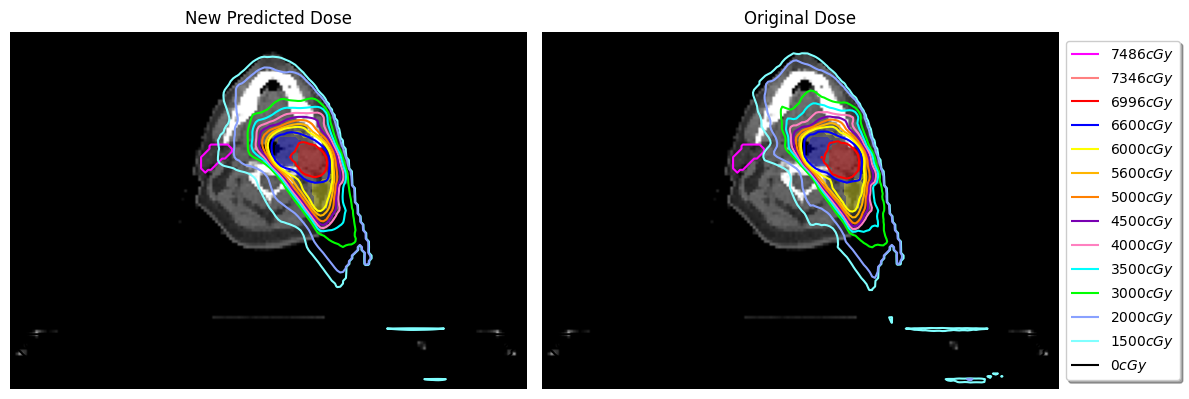

In [ ]:
z = 68

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 9))

for i, ax in enumerate(axes):
    ax.imshow(ct[z, ...], cmap='gray')
    ax.contourf(ptv_6996[z, ...], colors='red', alpha=0.35)
    ax.contourf(ptv_6600[z, ...], colors='blue', alpha=0.35)
    ax.contourf(ptv_6000[z, ...], colors='yellow', alpha=0.35)
    # ax.contourf(ptv_5600[z, ...], colors='green', alpha=0.35)

    ax.contour(mask_oar[z, ...], colors='magenta')

    ax.set_axis_off()

    if i == 0:
        ax.set_title('New Predicted Dose')
        ax.contour(
            new_dose[z, ...], levels=list(levels), colors=list(levels.values())
        )
    else:
        ax.set_title('Original Dose')
        iso_plot = plt.contour(
            start_dose[z, ...],
            levels=list(levels),
            colors=list(levels.values()),
        )

h, l = iso_plot.legend_elements(variable_name='D', str_format=dose_fmt)
l = [x.replace('D = ', '') for x in l]
h.reverse()
l.reverse()
plt.legend(
    h,
    l,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    shadow=True,
    fancybox=True,
)

fig.tight_layout()
plt.show()

## Example 2 - Reduce Left Parotid Dose

Same idea as before, except we just prompt for a decrease instead of an increase

In [ ]:
mask_oar = sitk.ReadImage(data_dir / 'SG_HN_309_mask_Larynx.nii.gz')
dilated_oar = dilate_region(mask_oar, radius=(5, 5, 5))

dilated_oar = sitk.GetArrayFromImage(dilated_oar).astype(bool)
# Not needed here but needed later when plotting
mask_oar = sitk.GetArrayFromImage(mask_oar).astype(bool)

rx = np.unique(mask_targets).max()
dose_ceil = 1.2 * rx

In [ ]:
vol_inputs = np.stack(
    [
        ct,
        start_dose / dose_ceil,
        mask_dose,
        mask_targets / dose_ceil,
        dilated_oar
        * mask_dose,  # cuts off any of the OAR expansion that's sticking outside the body
    ]
)
vol_inputs = np.expand_dims(vol_inputs, axis=0)

In [ ]:
highdose_mask = (vol_inputs[0, 3, ...] * dose_ceil == rx).astype(bool)
percentile = 50
dperc_ref = np.percentile(
    start_dose[highdose_mask], 100 - percentile, method='linear'
)

In [ ]:
prompt = 'Drop Dmean to the Larynx by 1500 cGy'

data = encode_request(
    vol_inputs=vol_inputs,
    prompt=prompt,
    norm_percentile=percentile,
    dperc_ref=dperc_ref,
    highdose_mask=highdose_mask,
    dose_ceil=dose_ceil,
    oar_mask=dilated_oar,
)

In [ ]:
new_dose = await make_prediction_request(
    data, server_url='http://10.105.70.181:7654/predict'
)

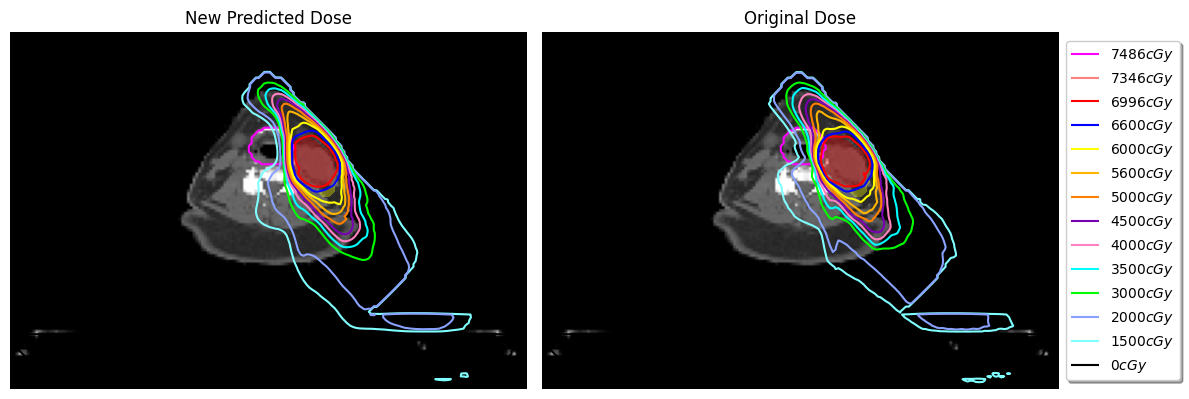

In [ ]:
z = 55

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 9))

for i, ax in enumerate(axes):
    ax.imshow(ct[z, ...], cmap='gray')
    ax.contourf(ptv_6996[z, ...], colors='red', alpha=0.35)
    ax.contourf(ptv_6600[z, ...], colors='blue', alpha=0.35)
    ax.contourf(ptv_6000[z, ...], colors='yellow', alpha=0.35)
    # ax.contourf(ptv_5600[z, ...], colors='green', alpha=0.35)

    ax.contour(mask_oar[z, ...], colors='magenta')

    ax.set_axis_off()

    if i == 0:
        ax.set_title('New Predicted Dose')
        ax.contour(
            new_dose[z, ...], levels=list(levels), colors=list(levels.values())
        )
    else:
        ax.set_title('Original Dose')
        iso_plot = plt.contour(
            start_dose[z, ...],
            levels=list(levels),
            colors=list(levels.values()),
        )

h, l = iso_plot.legend_elements(variable_name='D', str_format=dose_fmt)
l = [x.replace('D = ', '') for x in l]
h.reverse()
l.reverse()
plt.legend(
    h,
    l,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    shadow=True,
    fancybox=True,
)

fig.tight_layout()
plt.show()

In [ ]:
new_dose[mask_oar].mean() - start_dose[mask_oar].mean()

-1510.7879692352544